# **Análisis exploratorio de dataset Titanic de Kaggle**

**Objetivo:** Aplicar técnicas de estadística descriptiva y visualización para comprender la relación entre las variables con la supervivencia de un pasajero

---
## **Características del dataset**  
---
### **Tamaño:**

1309 filas y 14 columnas

---
### **Tipos de variables**
---
#### **Cualitativas:**
---

**pclass ->**	Clase del pasajero (1 = 1ra clase, 2 = 2da clase, 3 = 3ra clase)

**survived (BINARIA) ->** Supervivencia (0 = No, 1 = Sí)

**cabin ->** Número de cabina

**embarked ->** Puerto de embarque (C = Cherbourg, Q = Queenstown, S = Southampton)

**boat ->** Bote salvavidas (si sobrevivió)

**body ->**	Número de identificación del cuerpo (si no sobrevivió y fue recuperado)

**home.dest	->** Hogar/Destino

**name, sex (BINARIA) ->** nombre y sexo del pasajero

**ticket ->** número de boleto

---
### **Cuantitativas**
---

**age ->** edad del pasajero

**sibsp	->** Número de hermanos/cónyuges a bordo

**parch	->** Número de padres/hijos a bordo

**fare ->** Tarifa del pasajero

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
url = "https://raw.githubusercontent.com/IvTole/MachineLearning_InferenciaBayesiana_CUGDL/refs/heads/main/data/titanic/titanic.csv"
df = pd.read_csv(url)
df

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,"Zabour, Miss. Hileni",female,14.50,1,0,2665,14.4542,NaN,C,NaN,328.0,NaN
1305,3,0,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,NaN,NaN,NaN
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.50,0,0,2656,7.2250,NaN,C,NaN,304.0,NaN
1307,3,0,"Zakarian, Mr. Ortin",male,27.00,0,0,2670,7.2250,NaN,C,NaN,NaN,NaN


# **Análisis univariado**

**Objetivo:** entender las variables y describirlas , con el fin de decidir cuáles son útiles para predecir la supervivencia de un pasajero, planteando hipótesis que se confirmarán en la sección de análisis bivariado

### **Conceptos base:**

**Data leakage (fuga de información):** información que no estaría disponible en el momento de la predicción y que revela la variable objetivo.

**Cardinalidad:** número de categorías distintas en una variable categórica.

Una alta cardinalidad puede causar:
- overfitting
- ruido
- modelos más complejos

In [ ]:
df.shape

(1309, 14)

In [ ]:
#NaN (Not a number)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   int64  
 1   survived   1309 non-null   int64  
 2   name       1309 non-null   object 
 3   sex        1309 non-null   object 
 4   age        1046 non-null   float64
 5   sibsp      1309 non-null   int64  
 6   parch      1309 non-null   int64  
 7   ticket     1309 non-null   object 
 8   fare       1308 non-null   float64
 9   cabin      295 non-null    object 
 10  embarked   1307 non-null   object 
 11  boat       486 non-null    object 
 12  body       121 non-null    float64
 13  home.dest  745 non-null    object 
dtypes: float64(3), int64(4), object(7)
memory usage: 143.3+ KB


## **Variables con datos faltantes**

No existe un umbral universal para eliminar variables con valores nulos; la decisión depende del contexto y la relevancia de cada variable respecto al objetivo del análisis.

**Cabin:** número de cabina

**boat:** bote salvavidas (si sobrevivió)

**body:** número de identificación del cuerpo (si no sobrevivió y fue recuperado)

**home.dest:** hogar/destino

### **Proporción de datos faltantes**

**cabin:**

Aunque podría aportar información sobre la ubicación del pasajero dentro del barco, presenta un alto porcentaje de valores faltantes, además de una estructura compleja. Por ello, se decide excluirla en esta etapa.

In [86]:
print(f"{df["cabin"].isnull().sum()/1309*100:.2f}%")

77.46%


**boat:**

La ausencia de datos en esta variable no es aleatoria, ya que solo aplica a pasajeros que sobrevivieron. Sin embargo, contiene información posterior al evento (data leakage), por lo que no debe utilizarse en el modelo.

**body:**

Esta variable indica si el cuerpo fue recuperado tras el fallecimiento del pasajero. Dado que es una consecuencia directa de la variable objetivo, se considera data leakage y se elimina.

**home.dest:**

La proporción de datos faltantes es muy alta. Además, saber el origen y destino de un pasajero, no influye en la probabilidad de sobrevivir o no, ya que todos viajan en el mismo medio

In [87]:
print(f"{df["home.dest"].isnull().sum()/1309*100:.2f}%")

43.09%


## **Análisis de variables cuantitativas**

### **Edad:**

**Estadísticas:**

1. El 75 % de los pasajeros se encuentran por debajo de los 39 años. Tan solo el 25% son mayores de 39 hasta una edad máxima de 80 años.

**Hipótesis:**

La mayoría de los pasajeros son relativamente jóvenes. La edad podría influir en la sobrevivencia, ya que ciertos grupos (niños o adultos mayores) podrían haber tenido prioridad o desventaja.

### **Viajar con acompañantes o solos**

**Estadísticas:**

1. El 75% de los pasajeros podría tener hasta 1 hermano o cónyuge a bordo.
El 25% de los pasajeros tienen desde 2 hasta 8.
2. El 75% de los pasajeros no tiene padres ni hijos a bordo. Únicamente el 25% tienen de 1 a 9 familiares.

**Hipótesis:**
La mayoría de los pasajeros viajaban solos o con un solo acompañante. Esto podría influir en la sobrevivencia, ya que viajar en grupo puede afectar la toma de decisiones en situaciones de emergencia.

### **Tarifas**

**Estadísticas:**

1. El 75% de los boletos tienen un costo menor o igual que 31.28 dólares, mientras que el 25% se encuentran desde esa cantidad hasta un máximo de 512 dólares.

**Hipótesis:**

La distribución del precio es altamente asimétrica, con pocos valores extremadamente altos, lo que sugiere la presencia de diferentes niveles socioeconómicos. Esto está relacionado con la clase del pasajero y, por tanto, con la probabilidad de sobrevivencia.

En la siguiente sección se analizará la relación de estas variables con la sobrevivencia de los pasajeros

In [ ]:
#Aunque hay variables con números, no son cuantitativas: pclass, survived, body
df_cuantitativas = df.select_dtypes(include=["int64", "float64"]).drop(columns = ["pclass","survived","body"]) #filtrar variables numéricas y eliminar columnas
df_cuantitativas.describe()

,age,sibsp,parch,fare
count,1046.000000,1309.000000,1309.000000,1308.000000
mean,29.881138,0.498854,0.385027,33.295479
std,14.413493,1.041658,0.865560,51.758668
min,0.170000,0.000000,0.000000,0.000000
25%,21.000000,0.000000,0.000000,7.895800
50%,28.000000,0.000000,0.000000,14.454200
75%,39.000000,1.000000,0.000000,31.275000
max,80.000000,8.000000,9.000000,512.329200


## **Análisis de variables cualitativas**

In [88]:
#Seleccionar solo las categóricas
categoricas = df.select_dtypes(include=["object", "category"]) #object: cualquier texto (nombre), category: número limitado de categorías (sexo)

#Contar los valores de cada categórica
for col in categoricas.columns: #cada variable en la lista
    print(f"--- {col} ---")
    print(categoricas[col].value_counts())
    print()

--- name ---
name
Kelly, Mr. James                     2
Connolly, Miss. Kate                 2
Ilmakangas, Miss. Ida Livija         1
Ilieff, Mr. Ylio                     1
Ibrahim Shawah, Mr. Yousseff         1
                                    ..
Harris, Mr. George                   1
Harper, Rev. John                    1
Harper, Miss. Annie Jessie "Nina"    1
Harbeck, Mr. William H               1
Herman, Mr. Samuel                   1
Name: count, Length: 1307, dtype: int64

--- sex ---
sex
male      843
female    466
Name: count, dtype: int64

--- ticket ---
ticket
CA. 2343        11
CA 2144          8
1601             8
347082           7
S.O.C. 14879     7
                ..
349202           1
347466           1
347075           1
350043           1
348125           1
Name: count, Length: 929, dtype: int64

--- cabin ---
cabin
C23 C25 C27        6
B57 B59 B63 B66    5
G6                 5
D                  4
F4                 4
                  ..
F E46              1
F E

Algunas variables presentan alta cardinalidad (demasiados valores únicos), lo que limita su uso directo en modelos de machine learning, por lo tanto, se decide excluirlas, además de aquellas variables que se justificaron en la sección principal (home.dest, boat, cabin):

- Name

- Ticket

Las variables que aún se conservan para analizar son:

- Sex

- Embarked

- Age

- Fare

- Sibsp

- Parch

- Pclass

# **Análisis bivariado**

**Objetivo:** analizar la relación entre cada variable explicativa y la variable objetivo (survived), con el fin de identificar aquellas que tienen mayor influencia en la probabilidad de supervivencia.

## **Relación de variables categóricas con la supervivencia**

Dado que el coeficiente de correlación de Pearson no es adecuado para variables categóricas ni para relaciones no lineales, se utilizaron proporciones y visualizaciones para analizar la relación con la variable objetivo.

**Sex**

Se observa una diferencia clara en la proporción de supervivencia entre hombres y mujeres.

**Pclass**

La tasa de supervivencia disminuye conforme aumenta el número de clase (de primera a tercera).

**SibSp y Parch**

La relación con la supervivencia no es lineal. Se observan mayores tasas en pasajeros con pocos acompañantes.

**Embarked**

Puertos con distinta composición de clases (Q y S) presentan tasas similares de supervivencia.

### **Supervivencia en relación con el sexo**

In [28]:
survivors_sex = pd.crosstab(df["sex"],df["survived"])
survivors_sex

survived,0,1
sex,,
female,127,339
male,682,161


**Proporciones de supervivencia**

In [45]:
prop_sex = df.groupby("sex")["survived"].mean()
prop_sex

,survived
sex,
female,0.727468
male,0.190985


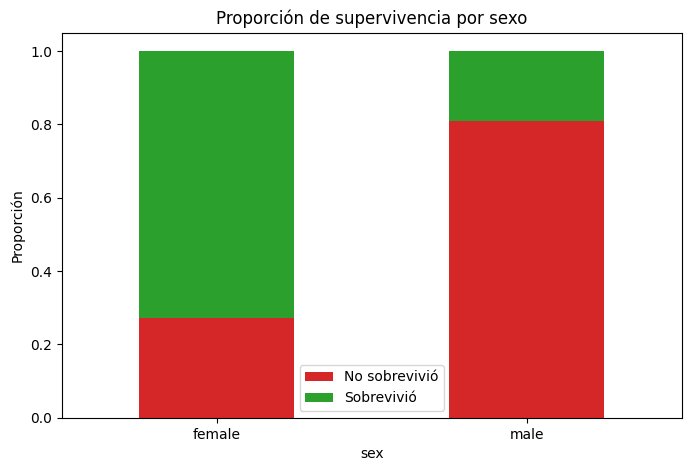

In [47]:
df_plot1 = pd.DataFrame({
    "No sobrevivió": 1 - prop_sex,
    "Sobrevivió": prop_sex
})

df_plot1.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5),
    color=["#d62728", "#2ca02c"]
)

plt.title("Proporción de supervivencia por sexo")
plt.ylabel("Proporción")
plt.xticks(rotation=0)
plt.show()

### **Supervivencia en relación con la clase**

In [30]:
survivors_class = pd.crosstab(df["pclass"],df["survived"])
survivors_class

survived,0,1
pclass,,
1,123,200
2,158,119
3,528,181


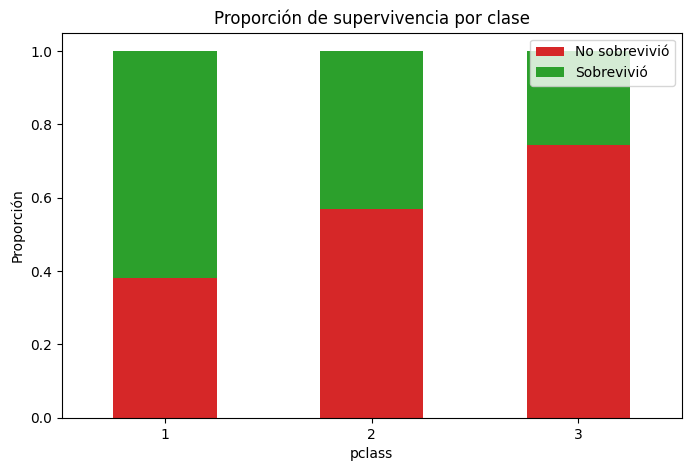

In [48]:
prop_class = df.groupby("pclass")["survived"].mean()
df_plot2 = pd.DataFrame({
    "No sobrevivió": 1 - prop_class,
    "Sobrevivió": prop_class
})

df_plot2.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5),
    color=["#d62728", "#2ca02c"]
)

plt.title("Proporción de supervivencia por clase")
plt.ylabel("Proporción")
plt.xticks(rotation=0)
plt.show()

### **Supervivencia en relación con la cantidad de hermanos/cónyuges a bordo**

In [52]:
pd.crosstab(df["sibsp"],df["survived"])

survived,0,1
sibsp,,
0,582,309
1,156,163
2,23,19
3,14,6
4,19,3
5,6,0
8,9,0


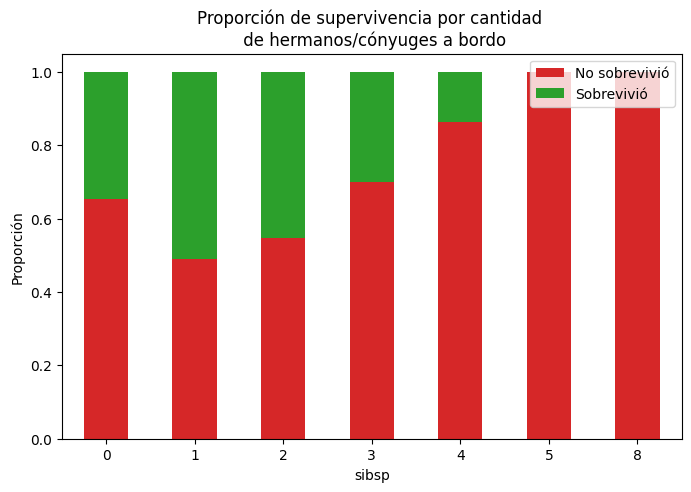

In [49]:
prop_sibsp = df.groupby("sibsp")["survived"].mean()
df_plot3 = pd.DataFrame({
    "No sobrevivió": 1 - prop_sibsp,
    "Sobrevivió": prop_sibsp
})

df_plot3.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5),
    color=["#d62728", "#2ca02c"]
)

plt.title("Proporción de supervivencia por cantidad \n de hermanos/cónyuges a bordo")
plt.ylabel("Proporción")
plt.xticks(rotation=0)
plt.show()

### **Supervivencia en relación con el número de padres e hijos a bordo**

In [51]:
pd.crosstab(df["parch"],df["survived"])

survived,0,1
parch,,
0,666,336
1,70,100
2,56,57
3,3,5
4,5,1
5,5,1
6,2,0
9,2,0


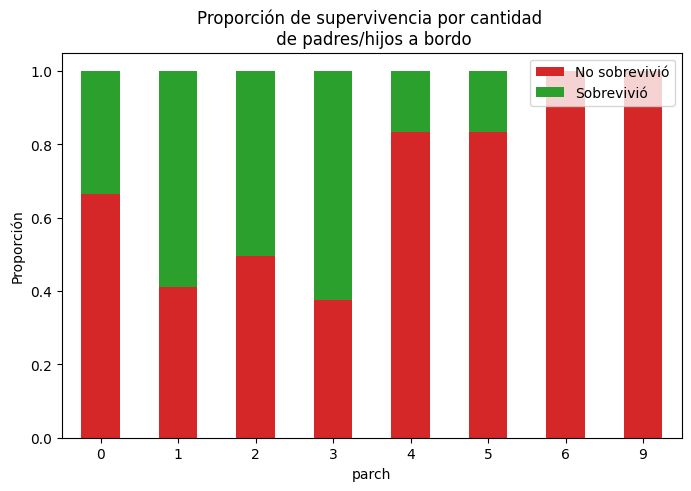

In [50]:
prop_parch = df.groupby("parch")["survived"].mean()
df_plot4 = pd.DataFrame({
    "No sobrevivió": 1 - prop_parch,
    "Sobrevivió": prop_parch
})

df_plot4.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5),
    color=["#d62728", "#2ca02c"]
)

plt.title("Proporción de supervivencia por cantidad \n de padres/hijos a bordo")
plt.ylabel("Proporción")
plt.xticks(rotation=0)
plt.show()

### **Supervivencia en relación con el puerto de embarque**

In [59]:
df.groupby("embarked")["survived"].mean()

,survived
embarked,
C,0.555556
Q,0.357724
S,0.332604


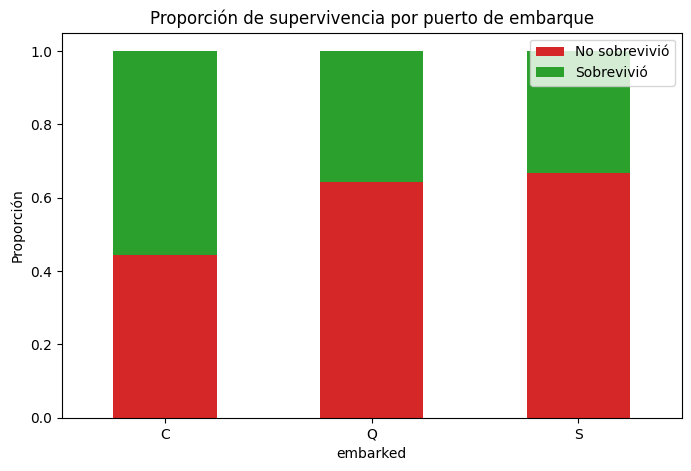

In [62]:
prop_embarked = df.groupby("embarked")["survived"].mean()
df_plot5 = pd.DataFrame({
    "No sobrevivió": 1 - prop_embarked,
    "Sobrevivió": prop_embarked
})

df_plot5.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5),
    color=["#d62728", "#2ca02c"]
)

plt.title("Proporción de supervivencia por puerto de embarque")
plt.ylabel("Proporción")
plt.xticks(rotation=0)
plt.show()

**Distribución de clases por embarque**

In [64]:
pd.crosstab(df["embarked"],df["pclass"])

pclass,1,2,3
embarked,,,
C,141,28,101
Q,3,7,113
S,177,242,495


## **Relación de variables numéricas con la supervivencia**

**Objetivo:** identificar diferencias entre grupos de sobrevivientes y no sobrevivientes

### **age**

Con base en el histograma de edades en relación con supervivencia, se observa que el grupo del que hubo menos sobrevivientes, si acaso nulos, es de entre 65 y 75 años. Sin embargo, de la mayoría de los grupos sobrevivieron alrededor de un 50%, es decir, no hay diferencia notable entre ellos


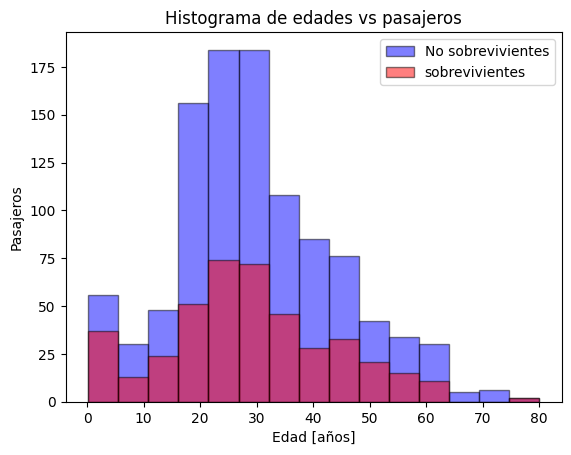

In [79]:
df_survivors = df[df["survived"]==1]
plt.hist(df['age'], bins = 15, alpha = 0.5 , edgecolor ="black", color="blue", label="No sobrevivientes")
plt.hist(df_survivors['age'], bins =15, alpha = 0.5 , edgecolor ="black", color="red", label="sobrevivientes") #alpha controla la transparencia de las barras 1.0 = intenso, 0.0 = invisible
plt.xlabel('Edad [años]')
plt.ylabel('Pasajeros')
plt.title('Histograma de edades vs pasajeros')
plt.legend(loc = 'upper right')
plt.show()

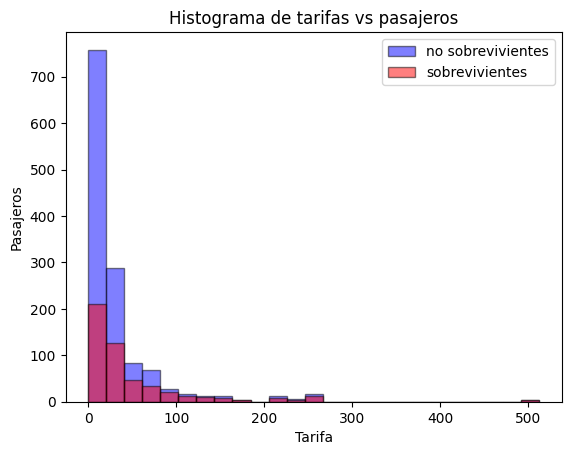

In [77]:
plt.hist(df['fare'], bins = 25, alpha = 0.5 , edgecolor ="black", color="blue", label="no sobrevivientes")
plt.hist(df_survivors['fare'], bins =25, alpha = 0.5 , edgecolor ="black", color="red", label="sobrevivientes")
plt.xlabel('Tarifa')
plt.ylabel('Pasajeros')
plt.title('Histograma de tarifas vs pasajeros')
plt.legend(loc = 'upper right')
plt.show()

## **Interpretación final**


---
### **Variables descartadas y transformaciones**
---
**cabin**

La variable Cabin es conceptualmente relevante, ya que refleja la ubicación del pasajero dentro del barco. Sin embargo, presenta un alto porcentaje de valores faltantes y una alta cardinalidad. Por ello, se propone transformarla en una variable binaria que indique únicamente la presencia o ausencia de cabina, capturando parcialmente su información sin introducir complejidad excesiva.

**boat**

La variable Boat no es útil para el modelado, ya que contiene información posterior al evento (solo disponible para sobrevivientes), lo que generaría data leakage.

**body**

De forma similar, la variable Body tampoco es útil, pues solo está presente en pasajeros fallecidos.

**otras variables**

Las variables Name, Ticket y Home/Dest funcionan como identificadores o contienen información no directamente relacionada con la supervivencia, por lo que se descartan.

---
### **Variables con mayor relación con la supervivencia**
---
**sex**

El sexo es una de las variables más influyentes. Se observa una diferencia clara en las tasas de supervivencia, siendo significativamente mayor en mujeres que en hombres, lo cual refleja patrones sociales como la prioridad de evacuación.

**pclass**

La clase muestra una relación directa con la supervivencia: a menor clase, menor probabilidad de sobrevivir. Esto sugiere que el nivel socioeconómico influyó en la ubicación dentro del barco y en el acceso a los botes salvavidas.

**fare**

El análisis de la distribución de tarifas muestra que la mayoría de los pasajeros se concentra en valores bajos, donde predominan los no sobrevivientes. A medida que aumenta la tarifa, se incrementa la proporción de sobrevivientes, lo que sugiere que el nivel económico, reflejado en el costo del boleto, está asociado con una mayor probabilidad de supervivencia

---
### **Variables con relación intermedia o contextual**
---
**Tamaño de familia (SibSp + Parch)**

Al analizar SibSp y Parch, se observa una relación no lineal con la supervivencia. Los pasajeros que viajaban con familias pequeñas (1–2 acompañantes) presentan mayores tasas de supervivencia, mientras que aquellos que viajaban solos o en familias grandes tienen menor probabilidad.

Por ello, se propone crear la variable:

df["FamilySize"] = df["SibSp"] + df["Parch"]

Esta variable resume mejor la estructura familiar y captura el efecto observado:

familias pequeñas → mayor supervivencia

familias grandes o pasajeros solos → menor supervivencia

**Puerto de embarque (Embarked)**

El puerto de embarque muestra diferencias en las tasas de supervivencia, destacando Cherbourg con mayor proporción. Sin embargo, al analizar su relación con la clase, se observa que esta variable está fuertemente influenciada por la distribución socioeconómica de los pasajeros.

Además, puertos como Queenstown y Southampton presentan tasas de supervivencia similares a pesar de tener distinta composición de clases, lo que sugiere que su influencia es limitada.

Por lo tanto, Embarked se considera una variable con efecto indirecto y débil.

---
### **Variables con menor influencia**
---
**Edad (Age)**

Aunque intuitivamente podría parecer relevante, el análisis muestra que la tasa de supervivencia se mantiene relativamente constante entre grupos de edad. Esto sugiere que la edad, por sí sola, no es un factor determinante en la supervivencia dentro de este dataset.

---
### **Conclusión final**
---
Las variables más relevantes para predecir la supervivencia son:

Sexo, debido a su fuerte impacto en las tasas de supervivencia

Fare, ya que captura de forma más precisa la posición socioeconómica y ubicación dentro del barco

Pclass, como variable estructural relacionada con el acceso a recursos

FamilySize, que refleja dinámicas de apoyo o dificultad durante la evacuación

La supervivencia en el Titanic no dependió de un solo factor, sino de una combinación de condiciones sociales y económicas donde la ubicación dentro del barco y las dinámicas sociales jugaron un papel clave.

Cabe destacar que estas observaciones brindan una intuición y entendimiento de la influencia de cada variable con la objetivo, sin embargo, se decide seleccionar las siguientes , con el fin de probar los resultados del modelo predictivo y verificar la importancia de cada una de ellas

### **Selección de variables**

In [3]:
# Creación de variable
df["familySize"] = df["sibsp"] + df["parch"]

# Selección de variables
df_selected = df[['survived', 'pclass', 'sex', 'fare', 'familySize','embarked','age']]

df_selected.to_csv('../data/processed/titanic_selected.csv', index=False)